# Predicting Irrigation Needs

Predict a class label (Low, Medium, High) for the Irrigation_Need target.

## 01. Importing Libraries and Configuration

In [1]:
# =========================
# 1. IMPORTS
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import shap
import warnings
warnings.filterwarnings("ignore")

## 2. Load Data - Target Encoding and Split

In [2]:
# =========================
# 2. LOAD DATA
# =========================
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e4/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e4/test.csv")

target_col = "Irrigation_Need"

# =========================
# 3. TARGET LABEL
# =========================
le = LabelEncoder()
train[target_col] = le.fit_transform(train[target_col])

X = train.drop(columns=[target_col])
y = train[target_col]
X_test = test.copy()

train.head()

# =========================
# 4. SPLIT
# =========================
X = train.drop(columns=[target_col])
y = train[target_col]
X_test = test.copy()

## 3. Handle Missing Data

In [3]:
# =========================
# 5. HANDLE MISSING VALUES
# =========================
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X_test[num_cols] = X_test[num_cols].fillna(X[num_cols].median())

for col in cat_cols:
    X[col] = X[col].fillna("Unknown")
    X_test[col] = X_test[col].fillna("Unknown")

## 4. Feature Engineering

In [4]:
# =========================
# 6. FEATURE INTERACTIONS
# =========================
def add_interactions(df):
    df = df.copy()
    
    # Pairwise interactions (top numeric features)
    for i in range(min(5, len(num_cols))):
        for j in range(i+1, min(5, len(num_cols))):
            f1, f2 = num_cols[i], num_cols[j]
            
            df[f"{f1}_x_{f2}"] = df[f1] * df[f2]
            df[f"{f1}_div_{f2}"] = df[f1] / (df[f2] + 1e-5)
    
    # Log transforms (stabilization)
    for col in num_cols[:5]:
        df[f"log_{col}"] = np.log1p(df[col])
    
    return df


X = add_interactions(X)
X_test = add_interactions(X_test)

## 5. Target Encoding

In [5]:
# =========================
# 6. TARGET ENCODING
# =========================
def target_encode(train, test, target, cat_cols, n_splits=5):
    train_enc = train.copy()
    test_enc = test.copy()
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for col in cat_cols:
        oof = np.zeros(len(train))
        test_mean = np.zeros(len(test))
        
        for tr_idx, val_idx in skf.split(train, target):
            X_tr, X_val = train.iloc[tr_idx], train.iloc[val_idx]
            y_tr = target.iloc[tr_idx]
            
            temp = X_tr.copy()
            temp["target"] = y_tr.values
            
            stats = temp.groupby(col)["target"].agg(["mean", "count"])
            smooth = (stats["mean"] * stats["count"] + target.mean()*10) / (stats["count"] + 10)
            
            oof[val_idx] = X_val[col].map(smooth)
            test_mean += test[col].map(smooth).fillna(target.mean()) / n_splits
        
        train_enc[col] = pd.Series(oof).fillna(target.mean())
        test_enc[col] = test_mean
    
    return train_enc, test_enc

X, X_test = target_encode(X, X_test, y, cat_cols)

# =========================
# 7. SCALING
# =========================
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)



## 6. Defining Model Parameters

In [6]:
# =========================
# 8. BASE MODELS (UPDATED)
# =========================
xgb = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.03,
                    subsample=0.85, colsample_bytree=0.85,
                    eval_metric='mlogloss', random_state=42)

lgb = LGBMClassifier(n_estimators=500, learning_rate=0.03,
                     num_leaves=40, random_state=42, verbose=-1)

rf = RandomForestClassifier(n_estimators=400, max_depth=14,
                            n_jobs=-1, random_state=42)

cat = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.03,
    loss_function='MultiClass',
    verbose=0,
    random_state=42
)

models = [xgb, lgb, rf, cat]


## 7. Feature Selection

In [7]:
# =========================
# 9. FEATURE SELECTION
# =========================
print("\n🔍 Feature Selection...")
lgb.fit(X, y)

importance = pd.Series(lgb.feature_importances_, index=X.columns)
selected_features = importance[importance > importance.mean()].index

X = X[selected_features]
X_test = X_test[selected_features]

print(f"Selected {len(selected_features)} features")




🔍 Feature Selection...
Selected 11 features


## 8. Stacking

In [8]:
# =========================
# 10. STACKING
# =========================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

n_classes = len(np.unique(y))
n_models = len(models)

oof_meta = np.zeros((len(X), n_models * n_classes))
test_meta = np.zeros((len(X_test), n_models * n_classes))

for i, model in enumerate(models):
    print(f"\n🚀 Training Model {i+1}: {model.__class__.__name__}")
    
    oof = np.zeros((len(X), n_classes))
    preds = np.zeros((len(X_test), n_classes))
    
    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        
        model.fit(X_tr, y_tr)
        
        oof[val_idx] = model.predict_proba(X_val)
        preds += model.predict_proba(X_test) / skf.n_splits
    
    oof_meta[:, i*n_classes:(i+1)*n_classes] = oof
    test_meta[:, i*n_classes:(i+1)*n_classes] = preds


🚀 Training Model 1: XGBClassifier

🚀 Training Model 2: LGBMClassifier

🚀 Training Model 3: RandomForestClassifier

🚀 Training Model 4: CatBoostClassifier


## 8. Meta Model

In [9]:
# =========================
# 11. META MODEL
# =========================
meta = LogisticRegression(max_iter=1000)
meta.fit(oof_meta, y)

final_probs = meta.predict_proba(test_meta)
final_preds = np.argmax(final_probs, axis=1)

final_labels = le.inverse_transform(final_preds)


## 9. Shap 


📊 SHAP analysis...


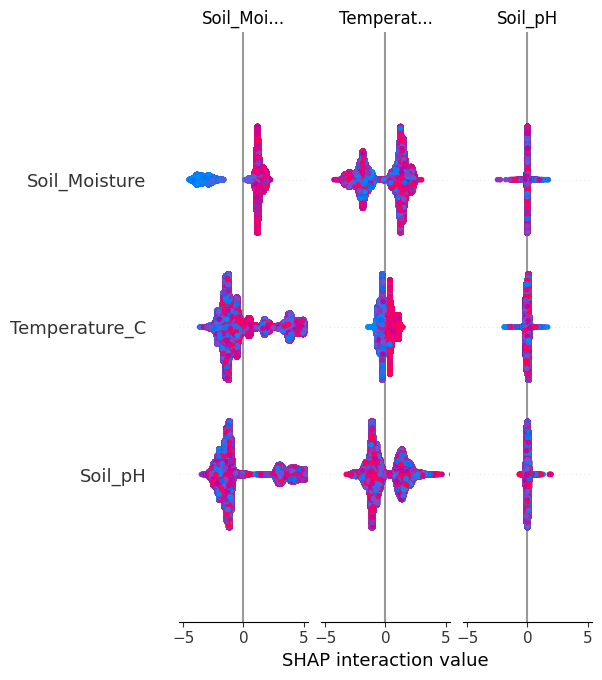

In [10]:
# =========================
# 12. SHAP (LightGBM)
# =========================
print("\n📊 SHAP analysis...")
explainer = shap.TreeExplainer(lgb)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)



## 10. Submission

In [11]:
# =========================
# 14. SAVE
# =========================
submission = pd.DataFrame({
    'id': test['id'],
    "Irrigation_Need": final_labels
})

submission.to_csv("submission.csv", index=False)

print("\n✅ Done: submission.csv created")
submission.head(20)


✅ Done: submission.csv created


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,Medium
9,630009,Low
